In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
file_path = "../../dataset/prepared/final_preprocessed_8PCs.csv"
df = pd.read_csv(file_path)

# Optional: Preview the first few rows
df.head()


,FP_IDX,FP_AMP1,FP_AMP2,CIR_PWR,MAX_NOISE,RXPACC,PREAM_LEN,CIR_PC1,CIR_PC2,CIR_PC3,CIR_PC4,CIR_PC5,CIR_PC6,CIR_PC7,CIR_PC8,RANGE
0,745.0,18712.0,10250.0,11855.0,967.0,611.0,1024.0,-10.899240,21.536682,-1.663086,-9.069089,-6.491534,-2.442977,-6.911036,-8.475677,3.90
1,749.0,11239.0,6313.0,18968.0,1133.0,447.0,1024.0,28.390261,-54.587130,-34.088007,-11.310028,-6.324734,-2.996781,2.770749,-1.643189,0.66
2,746.0,17845.0,18095.0,11380.0,1744.0,276.0,1024.0,55.250058,56.398613,22.352259,-9.362803,-8.034061,-17.334001,-0.793633,23.452083,1.19
3,748.0,18991.0,19444.0,13006.0,3904.0,283.0,1024.0,80.200057,13.423382,40.347520,-19.820667,7.579159,-11.896430,-12.592022,-1.772267,0.28
4,744.0,14781.0,10399.0,8025.0,1035.0,272.0,1024.0,20.229733,58.397655,-40.727859,16.409829,-12.187324,2.244173,-3.831716,16.710905,1.23


In [2]:
X = df.drop(columns=["RANGE"])
y = df["RANGE"]


In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=111)

k = 1 => CV Mean Squared Error: 3.1472
k = 5 => CV Mean Squared Error: 1.9457
k = 6 => CV Mean Squared Error: 1.9010
k = 7 => CV Mean Squared Error: 1.8675
k = 8 => CV Mean Squared Error: 1.8533
k = 10 => CV Mean Squared Error: 1.8317
k = 15 => CV Mean Squared Error: 1.8141
k = 20 => CV Mean Squared Error: 1.8073
k = 25 => CV Mean Squared Error: 1.8080
k = 30 => CV Mean Squared Error: 1.8140


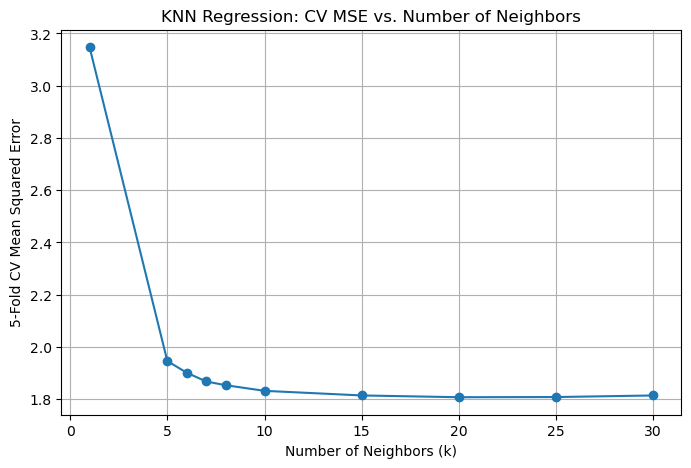


Best k is 20 with a CV MSE of 1.8073


In [4]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import cross_val_score
import numpy as np
import matplotlib.pyplot as plt

# Define candidate k values
k_values = [1, 5, 6, 7, 8, 10, 15, 20, 25, 30]
cv_mse = []

# Loop through each k value and perform 5-fold cross-validation on the training set
for k in k_values:
    knn_reg_cv = KNeighborsRegressor(n_neighbors=k, metric='minkowski', p=2)
    # Use negative MSE as the scoring metric (scikit-learn returns negative values for errors)
    scores = cross_val_score(knn_reg_cv, X_train, y_train, cv=5, scoring='neg_mean_squared_error')
    # Convert negative MSE to positive and compute the mean
    mean_mse = np.mean(-scores)
    cv_mse.append(mean_mse)
    print(f"k = {k} => CV Mean Squared Error: {mean_mse:.4f}")

# Plot the CV MSE versus k values
plt.figure(figsize=(8,5))
plt.plot(k_values, cv_mse, marker='o', linestyle='-')
plt.xlabel("Number of Neighbors (k)")
plt.ylabel("5-Fold CV Mean Squared Error")
plt.title("KNN Regression: CV MSE vs. Number of Neighbors")
plt.grid(True)
plt.show()

# Identify the best k (the one with the lowest CV MSE)
best_index = np.argmin(cv_mse)
best_k = k_values[best_index]
print(f"\nBest k is {best_k} with a CV MSE of {cv_mse[best_index]:.4f}")


In [ ]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

# 1. Create and train the KNN Regressor 
knn_reg = KNeighborsRegressor(n_neighbors=20, metric='minkowski', p=2)
knn_reg.fit(X_train, y_train)

# 2. Predict on the test set
y_pred_knn = knn_reg.predict(X_test)

# 3. Evaluate performance
mae_knn = mean_absolute_error(y_test, y_pred_knn)
mse_knn = mean_squared_error(y_test, y_pred_knn)
r2_knn = r2_score(y_test, y_pred_knn)
rmse = np.sqrt(mse_knn)

print("KNN Regression Performance on Test Set:")
print(f"Mean Absolute Error: {mae_knn:.4f}")
print(f"Mean Squared Error: {mse_knn:.4f}")
print(f"R-squared: {r2_knn:.4f}")
print(f"Root Mean Squared Error: {rmse:.4f}")

# 4. Plot Actual vs. Predicted values
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred_knn, alpha=0.5)
plt.xlabel("Actual RANGE")
plt.ylabel("Predicted RANGE")
plt.title("KNN Regression: Actual vs. Predicted RANGE")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.show()


NameError: name 'mse' is not defined

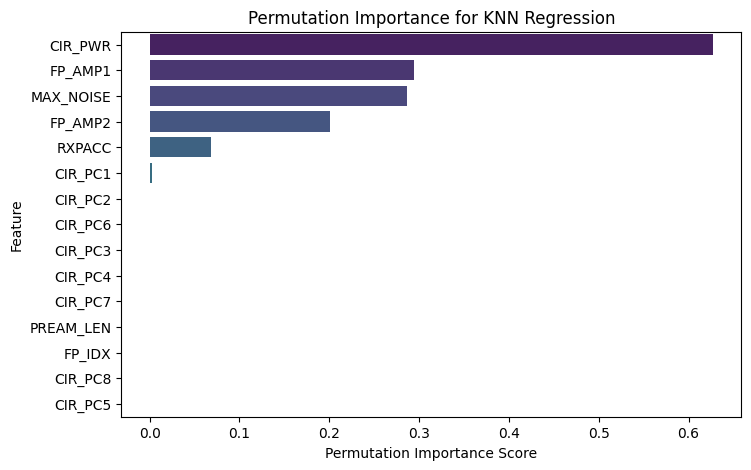

In [37]:
from sklearn.inspection import permutation_importance
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Make sure X_test doesn't include the target column "RANGE" if needed.
# For example, if you have X defined as df.drop(columns=["RANGE"]), then it's fine.
# Otherwise, adjust accordingly.

r = permutation_importance(knn_reg, X_test, y_test, n_repeats=10, random_state=111, scoring='neg_mean_squared_error')

# Convert the mean importance values into a pandas Series with feature names as the index
perm_importances = pd.Series(r.importances_mean, index=X_test.columns).sort_values(ascending=False)

plt.figure(figsize=(8,5))
ax = sns.barplot(x=perm_importances.values, 
                 y=perm_importances.index, 
                 hue=perm_importances.index, 
                 palette="viridis", 
                 dodge=False)
# Remove legend if created by Seaborn
if ax.get_legend() is not None:
    ax.get_legend().remove()

plt.xlabel("Permutation Importance Score")
plt.ylabel("Feature")
plt.title("Permutation Importance for KNN Regression")
plt.show()



- Based on feature importance, can remove **CIR_PC2/3/4/5/6/7/8, PREAM_LEN,FP_IDX** (for dataset final_preprocessed_8PCs.cvs)
    - Mean Absolute Error: 1.0659007142857142
    - Mean Squared Error: 1.8227857724206349
    - R-squared: 0.3376922343600083
  
- Based on feature importance, can remove **CIR_1/2/3/4/5/6/7/8, FP_IDX, NLOS** (for dataset final_preprocessed_8PCs_both.cvs)
    - Mean Absolute Error: 1.4031969444444443
    - Mean Squared Error: 3.265474011884921
    - R-squared: 0.413534751448136

- Based on feature importance, can remove **CIR_PC1/2/3/4/5/6/7/8, STDEV_NOISE, NLOS, FP_IDX** (for dataset final_preprocessed_8PCs_both_all.cvs)

    - Mean Absolute Error: 1.4261904365079363
    - Mean Squared Error: 3.362464653630952
    - R-squared: 0.3961156445706149